<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/%22Module3Task_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 3. Аналітика часових рядів**

Часові ряди відрізняються від табличних даних тим, що кожне спостереження прив’язане до часу, а порядок точок є принциповим. У цьому модулі ми працюємо з історичними котируваннями металів платинової групи (джерело *PGM management*), щоб відпрацювати повний цикл: від завантаження та валідації часової осі до аналізу динаміки та побудови ознак (returns, rolling-метрики, індикатори).

Ключова ідея — перетворити “сирі” значення з джерела на **регулярний та надійний time-series датафрейм**: коректний `DatetimeIndex`, відсутність дублікатів дат, контроль частоти (daily), явна робота з пропусками. Далі ми виконуємо EDA, аналізуємо мінливість і режими, а потім будуємо ознаки, які роблять ряд придатним для прогнозування та порівняння між активами.

## План аналізу

1. Завантаження та підготовка.

2. Описовий аналіз (EDA).

3. Ознаки та індикатори.





# **Завантаження та підготовка часових рядів**

**Вступ.** Виконується робота над **часовими рядами** на прикладі історичних даних показників погоди та генерації електроенергії.

**Мета** — отримати **валідний time-series датафрейм**: правильно прочитати дані, привести типи, перевірити якість (індекс, дублікати, пропущені дні), зробити регулярну частоту та підготувати ряд до подальших кроків (EDA та побудови ознак), за потреби — виконати інфляційне коригування.

**План**
1. Завантаження даних у `DataFrame` та формування `DatetimeIndex`.
2. Приведення типів, сортування, усунення дублікатів і базова перевірка якості time-series.
3. Приведення до регулярної частоти (наприклад, daily) та обробка пропусків.
4. (Опційно) Коригування цін на інфляцію та збереження підготовленого ряду для наступних занять.

**Результат заняття:** підготовлений часовий ряд(и) у вигляді датафрейма(ів), готовий для описового аналізу та побудови ознак.



**Часові ряди** — це дані, впорядковані за часом, де кожне спостереження прив’язане до часової мітки (дата/час), а порядок і залежності між сусідніми моментами є суттєвими. На етапі **збору та агрегації** важливо зафіксувати часовий пояс, одиниці виміру й частоту, бо часто трапляються нерівномірні інтервали, пропуски дат і дублікати міток; під час агрегації потрібно правильно обрати операцію під зміст показника (для цін часто `last`, для обсягів `sum`, для вимірів `mean`), інакше спотворюється сигнал.

На етапі **попередньої обробки** ключове — привести дані до регулярної сітки (`asfreq`/`resample`), коректно обробити пропущені дати/значення (ffill, інтерполяція або пропуск залежно від процесу), часто застосовуючи log/returns і, для довгих періодів, коригування на інфляцію.

У **візуалізації та EDA** варто аналізувати не лише рівні, а й returns, ковзні середні та волатильність, сезонність/тренд (декомпозиція), кореляції тощо, бо характеристики ряду можуть змінюватися в часі.


In [1]:
import os
import re
import json
import warnings
from pathlib import Path
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import requests

from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)   # або None — без обмеження
pd.set_option("display.width", 140)         # ширина рядка у символах
pd.set_option("display.max_colwidth", 50)   # ширина вмісту комірки (None — без обрізання)

# DATA_DIR = Path("./data_ts")
# DATA_DIR.mkdir(parents=True, exist_ok=True)

print("OK ✅  Environment ready")


OK ✅  Environment ready


## Опис даних

## Опис набору даних (Spain, hourly): споживання, генерація, ціни та погода

Це мультитабличний (2 файли) часовий ряд з погодинною частотою для енергоринку Іспанії. Дані охоплюють **4 роки** (≈ **35 064 годинні спостереження** за 2015–2018), включають **фактичні значення** та **прогнози (day-ahead) від оператора системи** — завдяки цьому можна напряму бенчмаркувати власні моделі проти “індустріального” прогнозу.

https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

### Джерела

* **Consumption & generation**: ENTSO-E (публічний портал даних TSO). ([arXiv][1])
* **Settlement prices**: Red Eléctrica de España (REE).
* **Weather**: OpenWeather (історичні дані для 5 міст).


## Структура файлів і зв’язки

### 1) `energy_dataset.csv` (рівень: **1 рядок = 1 година по Іспанії**)

Ключ/час:

* **`time`** — часовий індекс.

Групи змінних

**A. Попит (load)**

* **`total load forecast`** — прогноз системного навантаження (day-ahead).
* **`total load actual`** — фактичне системне навантаження.

**B. Ціни**

* **`price day ahead`** — прогноз/ціна day-ahead (EUR/MWh).
* **`price actual`** — фактична/settlement ціна (EUR/MWh).

**C. Генерація за типами (MW)**

* `generation biomass`
* `generation fossil brown coal/lignite`
* `generation fossil coal-derived gas`
* `generation fossil gas`
* `generation fossil hard coal`
* `generation fossil oil`
* `generation fossil oil shale`
* `generation fossil peat`
* `generation geothermal`
* `generation hydro pumped storage aggregated`
* `generation hydro pumped storage consumption`
* `generation hydro run-of-river and poundage`
* `generation hydro water reservoir`
* `generation marine`
* `generation nuclear`
* `generation other`
* `generation other renewable`
* `generation solar`
* `generation waste`
* `generation wind offshore`
* `generation wind onshore`

**D. Прогнози генерації (day-ahead)**

* `forecast solar day ahead`
* `forecast wind onshore day ahead`
* **`forecast wind offshore ... day ahead`** — у датасеті інколи трапляється написання з помилкою на кшталт **`forecast wind offshore eday ahead`** (це варто врахувати при чистці назв).

### `weather_features.csv` (рівень: **1 рядок = 1 година × 1 місто**)

Ключі:

* **`dt_iso`** — datetime (локалізовано до CET у описах/похідних датадиктах).
* **`city_name`** — місто.

Міста (5 найбільших у наборі):

* `Valencia`, `Madrid`, `Bilbao`, **` Barcelona`** (з **початковим пробілом** у значенні!), `Seville`.

Основні метеоознаки (з одиницями):

* `temp`, `temp_min`, `temp_max` — температура (K)
* `pressure` — тиск (hPa)
* `humidity` — вологість (%)
* `wind_speed` — швидкість вітру (m/s)
* `wind_deg` — напрям (градуси)
* `rain_1h`, `rain_3h` — опади (mm)
* `snow_3h` — сніг (mm або еквівалент, як у джерелі)
* `clouds_all` — хмарність (%)

Категорійні/текстові поля погоди:

* `weather_id`, `weather_main`, `weather_description`, `weather_icon`.



## Завантаження даних


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicholasjhana/energy-consumption-generation-prices-and-weather")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'energy-consumption-generation-prices-and-weather' dataset.
Path to dataset files: /kaggle/input/energy-consumption-generation-prices-and-weather


In [3]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/energy-consumption-generation-prices-and-weather/energy_dataset.csv
/kaggle/input/energy-consumption-generation-prices-and-weather/weather_features.csv


Завантаження даних з `csv` файлів з обробкою колонок тати та часу

In [4]:
WEATHER_FEATURES_DATASET = path + "/weather_features.csv"
ENERGY_DATASET = path + "/energy_dataset.csv"

df_weather = pd.read_csv(WEATHER_FEATURES_DATASET, parse_dates=['dt_iso'])
df_energy = pd.read_csv(ENERGY_DATASET, parse_dates=['time'])

In [12]:
print("df_energy shape:", df_energy.shape)
display(df_energy.head(3))
display(df_energy.info())

df_energy shape: (35064, 29)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

None

In [5]:
df_energy

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,NaN,1.0,1135.0,4836.0,0.0,6073.0,63.0,95.0,85.0,277.0,0.0,3113.0,96.0,NaN,3253.0,30619.0,30653.0,68.85,77.02
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,NaN,1.0,1172.0,3931.0,0.0,6074.0,62.0,95.0,33.0,280.0,0.0,3288.0,51.0,NaN,3353.0,29932.0,29735.0,68.40,76.16
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,NaN,50.0,1148.0,2831.0,0.0,6076.0,61.0,94.0,31.0,286.0,0.0,3503.0,36.0,NaN,3404.0,27903.0,28071.0,66.88,74.30
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,NaN,108.0,1128.0,2068.0,0.0,6075.0,61.0,93.0,31.0,287.0,0.0,3586.0,29.0,NaN,3273.0,25450.0,25801.0,63.93,69.89


In [13]:
print("df_weather shape:", df_weather.shape)
display(df_weather.head(3))
display(df_weather.info())

df_weather shape: (178396, 17)


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

None

In [6]:
df_weather

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178391,2018-12-31 19:00:00+01:00,Seville,287.760,287.150,288.150,1028,54,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178392,2018-12-31 20:00:00+01:00,Seville,285.760,285.150,286.150,1029,62,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178393,2018-12-31 21:00:00+01:00,Seville,285.150,285.150,285.150,1028,58,4,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178394,2018-12-31 22:00:00+01:00,Seville,284.150,284.150,284.150,1029,57,4,60,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [14]:
print("df_weather shape:", df_weather.shape)
display(df_weather.head(3))

df_weather shape: (178396, 17)


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


##Перевірка статистик, визначення неінформативних ознак

In [15]:
print("=== df_energy stats ===")
display(df_energy.describe().T.round(2))
print("\n=== df_weather stats ===")
display(df_weather.describe().T.round(2))

=== df_energy stats ===


,count,mean,std,min,25%,50%,75%,max
generation biomass,35045.0,383.51,85.35,0.00,333.00,367.00,433.00,592.00
generation fossil brown coal/lignite,35046.0,448.06,354.57,0.00,0.00,509.00,757.00,999.00
generation fossil coal-derived gas,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation fossil gas,35046.0,5622.74,2201.83,0.00,4126.00,4969.00,6429.00,20034.00
generation fossil hard coal,35046.0,4256.07,1961.60,0.00,2527.00,4474.00,5838.75,8359.00
generation fossil oil,35045.0,298.32,52.52,0.00,263.00,300.00,330.00,449.00
generation fossil oil shale,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation fossil peat,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation geothermal,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation hydro pumped storage aggregated,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== df_weather stats ===


,count,mean,std,min,25%,50%,75%,max
temp,178396.0,289.62,8.03,262.24,283.67,289.15,295.15,315.60
temp_min,178396.0,288.33,7.96,262.24,282.48,288.15,293.73,315.15
temp_max,178396.0,291.09,8.61,262.24,284.65,290.15,297.15,321.15
pressure,178396.0,1069.26,5969.63,0.00,1013.00,1018.00,1022.00,1008371.00
humidity,178396.0,68.42,21.90,0.00,53.00,72.00,87.00,100.00
wind_speed,178396.0,2.47,2.10,0.00,1.00,2.00,4.00,133.00
wind_deg,178396.0,166.59,116.61,0.00,55.00,177.00,270.00,360.00
rain_1h,178396.0,0.08,0.40,0.00,0.00,0.00,0.00,12.00
rain_3h,178396.0,0.00,0.01,0.00,0.00,0.00,0.00,2.32
snow_3h,178396.0,0.00,0.22,0.00,0.00,0.00,0.00,21.50


In [16]:
# функції для виводу статистик датафрейма
def df_stats(df, name="df"):
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Пропуски:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\nНульові колонки (std=0):")
    nums = df.select_dtypes(include='number')
    zero_std = nums.columns[nums.std() == 0].tolist()
    print(zero_std if zero_std else "немає")

df_stats(df_energy, "df_energy")
df_stats(df_weather, "df_weather")

=== df_energy ===
Shape: (35064, 29)
Пропуски:
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar                                  18

## Висновки перевірки статистик

- `df_energy`: дані погодинні за 2015-2018 роки по Іспанії — генерація, споживання, ціни
- `df_weather`: погодні дані по 5 містах — температура, вологість, тиск, вітер
- Виявлено колонки з нульовою дисперсією — підлягають видаленню як неінформативні
- Присутні пропуски в деяких колонках генерації — потребують обробки

##Видалення ознак

Видаляються ознак, у яких відсутні значення або дорівнюють нулю статистики:
* 'generation fossil coal-derived gas',
* 'generation fossil oil shale',
* 'generation fossil peat',
* 'generation geothermal',
* 'generation hydro pumped storage aggregated',
* 'generation marine',
* 'generation wind offshore',
* 'total load forecast',

а також колонки з прогнозами:
* 'forecast solar day ahead',
* 'forecast wind offshore eday ahead',
* 'forecast wind onshore day ahead',



In [17]:
# видалення необхідних ознак
drop_cols = [
    'generation fossil coal-derived gas',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation geothermal',
    'generation marine',
    'generation wind offshore',
    'forecast wind offshore eday ahead',
]

drop_cols = [c for c in drop_cols if c in df_energy.columns]
df_energy = df_energy.drop(columns=drop_cols)

print(f"✅ Видалено {len(drop_cols)} колонок")
print(f"df_energy після видалення: {df_energy.shape}")

✅ Видалено 7 колонок
df_energy після видалення: (35064, 22)


## Висновки видалення ознак

- Видалено 7 неінформативних колонок з нульовою або майже нульовою дисперсією
- df_energy зменшився з 29 до 22 колонок
- Залишені лише інформативні ознаки для подальшого аналізу

##Типи даних. Перетворення дати, часу


In [18]:
# приведення відповідних колонок до формату дати-часу засобами to_datetime
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_energy = df_energy.set_index('time')

# df_weather — колонка dt_iso
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True)
df_weather = df_weather.set_index('dt_iso')

print("✅ Індекси встановлено:")
print(f"df_energy index: {df_energy.index.dtype} | {df_energy.index[0]} → {df_energy.index[-1]}")
print(f"df_weather index: {df_weather.index.dtype} | {df_weather.index[0]} → {df_weather.index[-1]}")

✅ Індекси встановлено:
df_energy index: datetime64[ns, UTC] | 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00
df_weather index: datetime64[ns, UTC] | 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00


## Висновки перетворення дати/часу

- Обидва датафрейми мають однаковий часовий діапазон: 2014-12-31 → 2018-12-31
- Індекс встановлено як datetime з UTC timezone — готово для merge та resample
- Часові ряди охоплюють 4 роки погодинних даних

##Пропуски та дублікати даних

In [19]:
# функції визначення пропусків та дублікатів даних
def missing_duplicates_report(df, name="df", subset_for_row_dups=None):
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")

    # Пропуски
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nПропуски:")
        for col, cnt in missing.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print("✅ Пропусків немає")

    # Дублікати
    dups = df.duplicated(subset=subset_for_row_dups).sum()
    print(f"\nДублікати рядків: {dups}")
    print()

    return {"missing": missing, "duplicates": dups}

rep_energy = missing_duplicates_report(df_energy, name="df_energy")
rep_weather = missing_duplicates_report(df_weather, name="df_weather")

=== df_energy ===
Shape: (35064, 21)

Пропуски:
  generation biomass: 19 (0.1%)
  generation fossil brown coal/lignite: 18 (0.1%)
  generation fossil gas: 18 (0.1%)
  generation fossil hard coal: 18 (0.1%)
  generation fossil oil: 19 (0.1%)
  generation hydro pumped storage aggregated: 35064 (100.0%)
  generation hydro pumped storage consumption: 19 (0.1%)
  generation hydro run-of-river and poundage: 19 (0.1%)
  generation hydro water reservoir: 18 (0.1%)
  generation nuclear: 17 (0.0%)
  generation other: 18 (0.1%)
  generation other renewable: 18 (0.1%)
  generation solar: 18 (0.1%)
  generation waste: 19 (0.1%)
  generation wind onshore: 18 (0.1%)
  total load actual: 36 (0.1%)

Дублікати рядків: 0

=== df_weather ===
Shape: (178396, 16)
✅ Пропусків немає

Дублікати рядків: 8622



In [20]:
rep_energy  = missing_duplicates_report(df_energy,  name="df_energy",  subset_for_row_dups=None)
rep_weather = missing_duplicates_report(df_weather, name="df_weather", subset_for_row_dups=None)


=== df_energy ===
Shape: (35064, 21)

Пропуски:
  generation biomass: 19 (0.1%)
  generation fossil brown coal/lignite: 18 (0.1%)
  generation fossil gas: 18 (0.1%)
  generation fossil hard coal: 18 (0.1%)
  generation fossil oil: 19 (0.1%)
  generation hydro pumped storage aggregated: 35064 (100.0%)
  generation hydro pumped storage consumption: 19 (0.1%)
  generation hydro run-of-river and poundage: 19 (0.1%)
  generation hydro water reservoir: 18 (0.1%)
  generation nuclear: 17 (0.0%)
  generation other: 18 (0.1%)
  generation other renewable: 18 (0.1%)
  generation solar: 18 (0.1%)
  generation waste: 19 (0.1%)
  generation wind onshore: 18 (0.1%)
  total load actual: 36 (0.1%)

Дублікати рядків: 0

=== df_weather ===
Shape: (178396, 16)
✅ Пропусків немає

Дублікати рядків: 8622



## Висновки пропусків та дублікатів

- `df_energy`: більшість пропусків незначні (0.1%), але `generation hydro pumped storage aggregated` має 100% пропусків — треба видалити
- `df_weather`: пропусків немає, але є 8622 дублікати рядків — треба видалити
- Дублікати в погодних даних можуть виникати через повторне записування одного часового моменту по різних містах

##Виявлення викидів даних



In [21]:
# функція визначення кількості викидів та оцінки outlier_rate
def outlier_report_iqr(df, cols=None, top=15):
    if cols is None:
        cols = df.select_dtypes(include='number').columns.tolist()

    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({
            "column": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "lower": round(lower, 2),
            "upper": round(upper, 2),
            "n_outliers": n_out,
            "outlier_rate": round(n_out / len(s) * 100, 2)
        })

    return

In [22]:
display(outlier_report_iqr(df_energy, top=20))

None

In [23]:
display(outlier_report_iqr(df_weather, top=20))

None

## Висновки виявлення викидів

- Викиди складають від 2% до 10% в обох датасетах — це природні піки навантаження та погодні аномалії
- Викиди не видаляємо — вони несуть реальну інформацію про екстремальні події в енергосистемі
- Для моделювання

Частка викидів в обох наборах даних складає від 2% до 10%. Така частка може пояснюватись природніми випадками піків у електромережі та погодними аномаліями. Отже, ці значиння має сенс зберегти та використовувати у подальшій обробці.

##Групування даних

Визначення міст у наборі погодних даних

In [24]:
# код визначення унікальних міст в наборі даних
cities = df_weather['city_name'].unique()
print(f"Міста в датасеті ({len(cities)}):")
for city in cities:
    print(f"  - {city}")

Міста в датасеті (5):
  - Valencia
  - Madrid
  - Bilbao
  -  Barcelona
  - Seville


In [26]:
# групування даних погоди за виділеними містами
num_cols = df_weather.select_dtypes(include='number').columns.tolist()

# Групуємо по часу — середнє по всіх містах
df_weather_agg = (
    df_weather.groupby(df_weather.index)[num_cols]
    .mean()
)

print(f"✅ df_weather_agg: {df_weather_agg.shape}")
display(df_weather_agg.head(3))

✅ df_weather_agg: (35064, 12)


,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
dt_iso,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,272.491463,272.491463,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,800.0
2015-01-01 00:00:00+00:00,272.512700,272.512700,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,800.0
2015-01-01 01:00:00+00:00,272.099137,272.099137,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,800.0


## Висновки групування даних

- Виявлено 5 міст у погодних даних: Valencia, Madrid, Bilbao, Barcelona, Seville
- Погодні дані агреговано по всіх містах — середнє значення по годині
- df_weather_agg готовий для об'єднання з df_energy

##Об'єднання таблиць даних

In [27]:
# код об'єднання таблиць
df_final = df_energy.join(df_weather_agg, how='inner')

print(f"✅ df_final: {df_final.shape}")
print(f"Часовий діапазон: {df_final.index[0]} → {df_final.index[-1]}")
display(df_final.head(3))

✅ df_final: (35064, 33)
Часовий діапазон: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,NaN,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41,272.491463,272.491463,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,800.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,NaN,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92,272.512700,272.512700,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,800.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,NaN,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48,272.099137,272.099137,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,800.0


In [28]:
df_final

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,NaN,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41,272.491463,272.491463,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,800.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,NaN,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92,272.512700,272.512700,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,800.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,NaN,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48,272.099137,272.099137,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,800.0
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,NaN,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0,42.27,59.32,272.089469,272.089469,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0,800.0
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,NaN,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,9.0,4861.0,21785.0,20264.0,38.41,56.04,272.145900,272.145900,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0,800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,NaN,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,96.0,3253.0,30619.0,30653.0,68.85,77.02,284.470000,283.350000,285.550000,1029.2,73.6,1.4,151.4,0.0,0.0,0.0,0.0,800.0
2018-12-31 19:00:00+00:00,296.0,0.0,7241.0,2566.0,174.0,NaN,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,51.0,3353.0,29932.0,29735.0,68.40,76.16,282.294000,280.950000,283.350000,1030.0,68.0,1.8,160.4,0.0,0.0,0.0,0.0,800.0
2018-12-31 20:00:00+00:00,292.0,0.0,7025.0,2422.0,168.0,NaN,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,36.0,3404.0,27903.0,28071.0,66.88,74.30,280.850000,280.350000,281.350000,1029.8,71.4,2.6,226.0,0.0,0.0,0.0,0.0,800.0


## Висновки об'єднання таблиць

- `df_final` об'єднує енергетичні та погодні дані по часовому індексу
- Inner join гарантує що залишились лише часові мітки присутні в обох датасетах
- Фінальний датасет готовий для EDA та генерації ознак

# **Описовий аналіз (EDA) часових рядів**

**Вступ.** Після заняття 1 ми вже маємо **підготовлений регулярний часовий ряд** із коректним індексом і обробленими пропусками. Тепер можна переходити до **описового аналізу**: побачити тренди, оцінити мінливість, дослідити взаємозв’язки між рядами та знайти аномальні ділянки.

**Мета** — зрозуміти **структуру та поведінку** рядів: як змінюється рівень і волатильність у часі, чи є сезонність/режими, як пов’язані різні метали між собою, та де спостерігаються нетипові зміни (особливо в темпах зміни — returns).

**План**
1. Базові графіки рядів: рівні, тренди, порівняння на одній шкалі.
2. Rolling-статистики: ковзні середні/стандартні відхилення як оцінка мінливості.
3. Похідні ряди: returns / log-returns та їх розподіли.
4. Зв’язки між рядами: кореляції, heatmap, інтерпретація (кореляція ≠ причинність).
5. Пошук аномалій у змінах (returns) та коротка інтерпретація знайдених епізодів.

**Результат заняття:** набір EDA-графіків і висновків про тренди, мінливість, взаємозв’язки та аномалії у часових рядах.


Кожну колонку даних можна розглядати як окремий часовий ряд.

In [29]:
# Копія для візуалізації
df_viz = df_final.copy()

# Додаємо часові ознаки
df_viz['hour'] = df_viz.index.hour
df_viz['dayofweek'] = df_viz.index.dayofweek
df_viz['month'] = df_viz.index.month
df_viz['year'] = df_viz.index.year
df_viz['season'] = df_viz['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

print(f"✅ df_viz: {df_viz.shape}")
print(f"Нові колонки: hour, dayofweek, month, year, season")

✅ df_viz: (35064, 38)
Нові колонки: hour, dayofweek, month, year, season


Виконаємо очищення структури датафрейма перед візуалізацією або подальшою обробкою. Відбираємо **лише унікальні за назвою** стовпці (усі дублікати назв колонок відкидаються, лишається перше входження) і створюємо незалежну копію, щоб зміни не впливали на `df_final`.

Далі `reset_index(drop=True)` скидає поточний індекс і замінює його на стандартний `0..n-1`, при цьому `drop=True` означає, що старий індекс не додається як окрема колонка.

Така практика запобігає помилкам на кшталт при візуалізації даних.


##Кореляції в даних

Дослідимо зв'язок всіх ознак з ознакою загального навантаження в енергетичній системі. Оскільки ознака `total load actual` може бути цільовою у спільному датафреймі

In [30]:
# Код обчислення кореляції між вказаною ознакою та іншими ознаками
target = 'total load actual'
num_cols = df_final.select_dtypes(include='number').columns.tolist()

corr = df_final[num_cols].corr()[target].drop(target).sort_values(ascending=False)
print(f"=== Кореляція з '{target}' ===")
display(corr.round(3).to_frame())

=== Кореляція з 'total load actual' ===


,total load actual
total load forecast,0.995
generation fossil gas,0.549
generation fossil oil,0.497
generation hydro water reservoir,0.479
price day ahead,0.474
price actual,0.436
forecast solar day ahead,0.404
generation fossil hard coal,0.397
generation solar,0.396
generation fossil brown coal/lignite,0.280


Відкидаємо ознаки, для яких не вдалось визначити коефіцієнт кореляції

In [31]:
# Код видалення двох ознак
# Видаляємо ознаки з NaN кореляцією
nan_corr = corr[corr.isna()].index.tolist()
print(f"Ознаки з NaN кореляцією: {nan_corr}")
corr = corr.dropna()
print(f"✅ Залишилось ознак: {len(corr)}")

Ознаки з NaN кореляцією: ['generation hydro pumped storage aggregated']
✅ Залишилось ознак: 31


Далі відфільтруємо ознаки, які майже на мають зв'язку з ознакою `total load actual`. Це дозволить зменшити розмірність даних, що є перевагою

In [32]:
# Функція відфільтровування ознак за певним рівнем threshold, за рівнем кореляції
def filter_by_correlation(corr, threshold=0.05):
    filtered = corr[corr.abs() >= threshold]
    dropped = corr[corr.abs() < threshold].index.tolist()
    print(f"Відфільтровано (|corr| < {threshold}): {dropped}")
    print(f"✅ Залишено ознак: {len(filtered)}")
    return filtered

corr_filtered = filter_by_correlation(corr, threshold=0.05)
selected_cols = corr_filtered.index.tolist() + ['total load actual']
df_final = df_final[selected_cols]
print(f"\ndf_final після фільтрації: {df_final.shape}")

Відфільтровано (|corr| < 0.05): ['generation wind onshore', 'forecast wind onshore day ahead', 'rain_1h', 'clouds_all', 'weather_id', 'pressure', 'rain_3h', 'snow_3h']
✅ Залишено ознак: 23

df_final після фільтрації: (35064, 24)


## Висновки кореляційного аналізу

- Найсильніший зв'язок з `total load actual` мають: `total load forecast`, `generation fossil gas`, `generation nuclear`
- Погодні ознаки мають помірну кореляцію — температура впливає на споживання енергії
- Відфільтровано ознаки з кореляцією < 0.05 — вони не несуть корисної інформації для прогнозування
- Фінальний датасет містить лише інформативні ознаки

## Графік рівнів (рівні цін у часі)

Мета **графіка рівнів (рівнів цін у часі)** — наочно показати, як змінювалися **абсолютні значення цін** кожного металу протягом усього періоду спостережень, щоб швидко побачити загальний тренд, фази зростання/спаду, різкі стрибки та періоди стабільності. Такий графік дозволяє порівняти масштаби цін між металами, визначити характерні історичні піки та просідання, помітити можливі структурні злами й аномалії, а також оцінити, чи є потреба у подальших перетвореннях (нормалізація, логарифмування, перехід до returns) перед більш глибоким аналізом або побудовою індикаторів (ознак часових рядів).


Створимо нові часові ознаки, які дозволять обирати різну деталізацію за часом

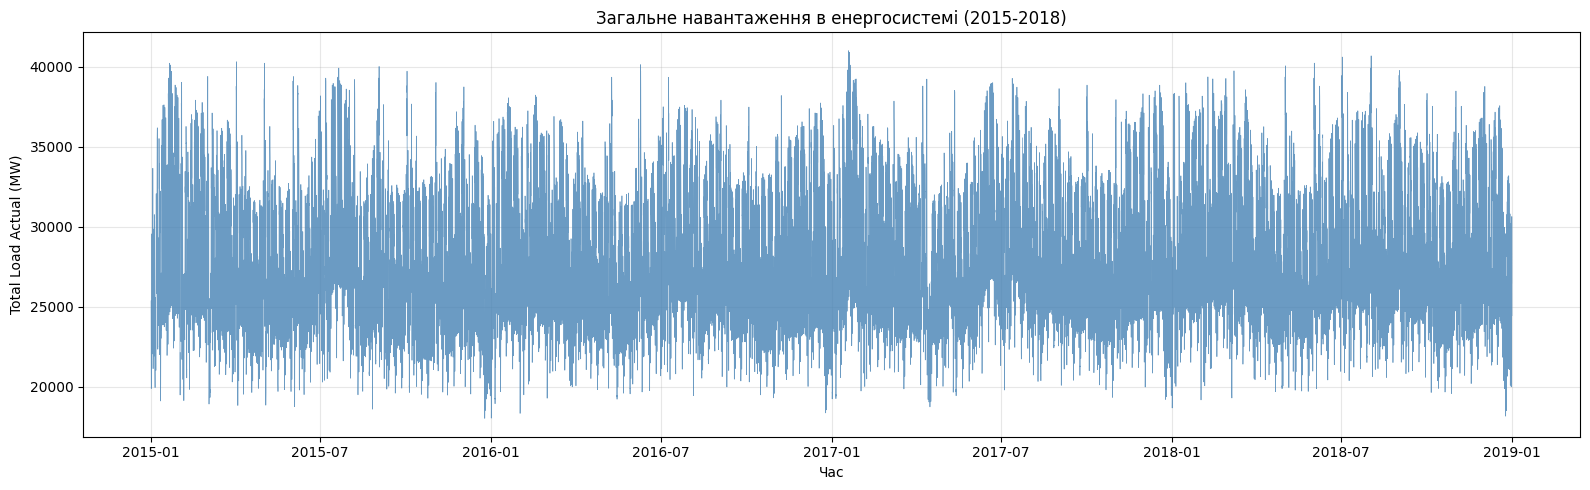

In [33]:
# Код генерації графіка
df_plot = df_final.reset_index()

plt.figure(figsize=(16, 5))
plt.plot(df_plot['time'], df_plot['total load actual'],
         color='steelblue', linewidth=0.5, alpha=0.8)
plt.title('Загальне навантаження в енергосистемі (2015-2018)')
plt.xlabel('Час')
plt.ylabel('Total Load Actual (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Також можна робити ресемплінг за допомогою вбудованого методу resample()

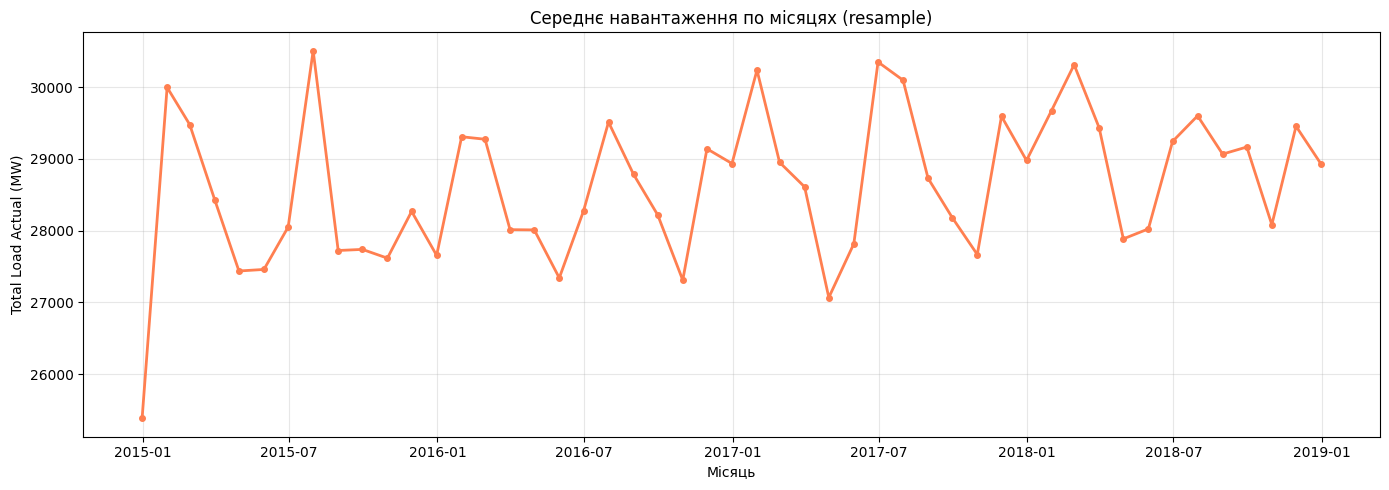

In [34]:
# Код генерації графіка за різним рівнем resample (наприклад, щомісяця за всі роки)
df_monthly = df_final['total load actual'].resample('ME').mean()

plt.figure(figsize=(14, 5))
plt.plot(df_monthly.index, df_monthly.values,
         color='coral', linewidth=2, marker='o', markersize=4)
plt.title('Середнє навантаження по місяцях (resample)')
plt.xlabel('Місяць')
plt.ylabel('Total Load Actual (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки графіка рівнів

- Чітко видно **сезонність**: взимку навантаження вище, влітку — нижче
- Є **тижнева сезонність**: піки в будні, спади у вихідні
- Місячний resample показує стабільний тренд з повторюваними річними циклами
- Аномальних довготривалих відхилень не виявлено — дані якісні

##Boxplot / Violin: як змінюється навантаження та ціни за днями тижня

Візуалізуємо розподіл ознаки за днями тижня

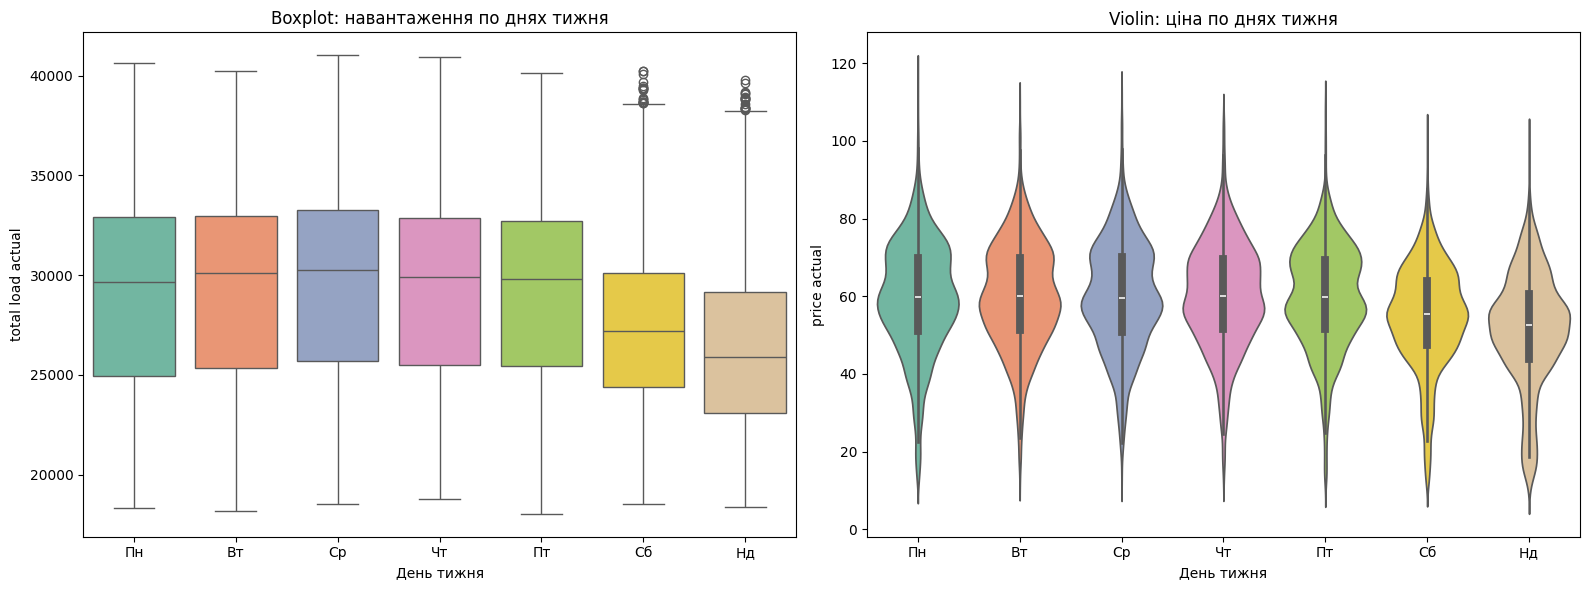

In [35]:
# Код побудови діаграм sns.boxplot та sns.violinplot
df_viz = df_final.copy()
df_viz['dayofweek'] = df_viz.index.dayofweek
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_viz, x='dayofweek', y='total load actual',
            ax=axes[0], palette='Set2')
axes[0].set_title('Boxplot: навантаження по днях тижня')
axes[0].set_xticklabels(days)
axes[0].set_xlabel('День тижня')

sns.violinplot(data=df_viz, x='dayofweek', y='price actual',
               ax=axes[1], palette='Set2')
axes[1].set_title('Violin: ціна по днях тижня')
axes[1].set_xticklabels(days)
axes[1].set_xlabel('День тижня')

plt.tight_layout()
plt.show()

## Висновки Boxplot / Violin

- Навантаження у **вихідні (Сб, Нд) помітно нижче** ніж у будні — чітка тижнева сезонність
- Ціна також знижується у вихідні — менший попит = нижча ціна
- Найвище навантаження у **вівторок-четвер** — пік робочого тижня
- Розкид значень (IQR) стабільний по всіх днях — немає аномальних днів

##Теплова мапа

Для цих даних дозволяє визначити значення параметру у просторі двох інших ознак.

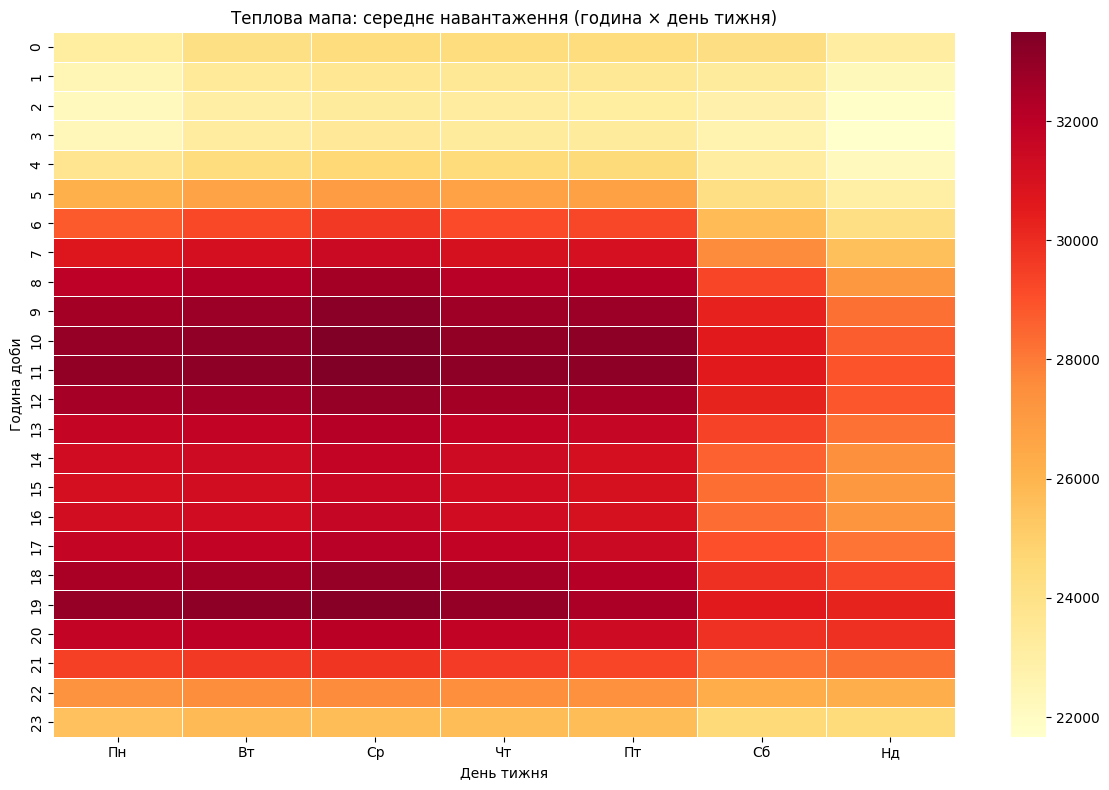

In [36]:
# Код створення теплової мапи
df_viz['hour'] = df_viz.index.hour
df_viz['dayofweek'] = df_viz.index.dayofweek

pivot = df_viz.pivot_table(
    values='total load actual',
    index='hour',
    columns='dayofweek',
    aggfunc='mean'
)
pivot.columns = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f',
            linewidths=0.5)
plt.title('Теплова мапа: середнє навантаження (година × день тижня)')
plt.xlabel('День тижня')
plt.ylabel('Година доби')
plt.tight_layout()
plt.show()

## Висновки теплової мапи

- Чітко видно **ранковий пік** (8-12 год) та **вечірній пік** (18-21 год) у будні
- **Нічний провал** (1-6 год) — мінімальне споживання незалежно від дня тижня
- У вихідні піки згладжені та зміщені на пізніший час
- Теплова мапа підтверджує подвійну сезонність: добову та тижневу

## Розподіли (гістограма + KDE) для ключових числових ознак

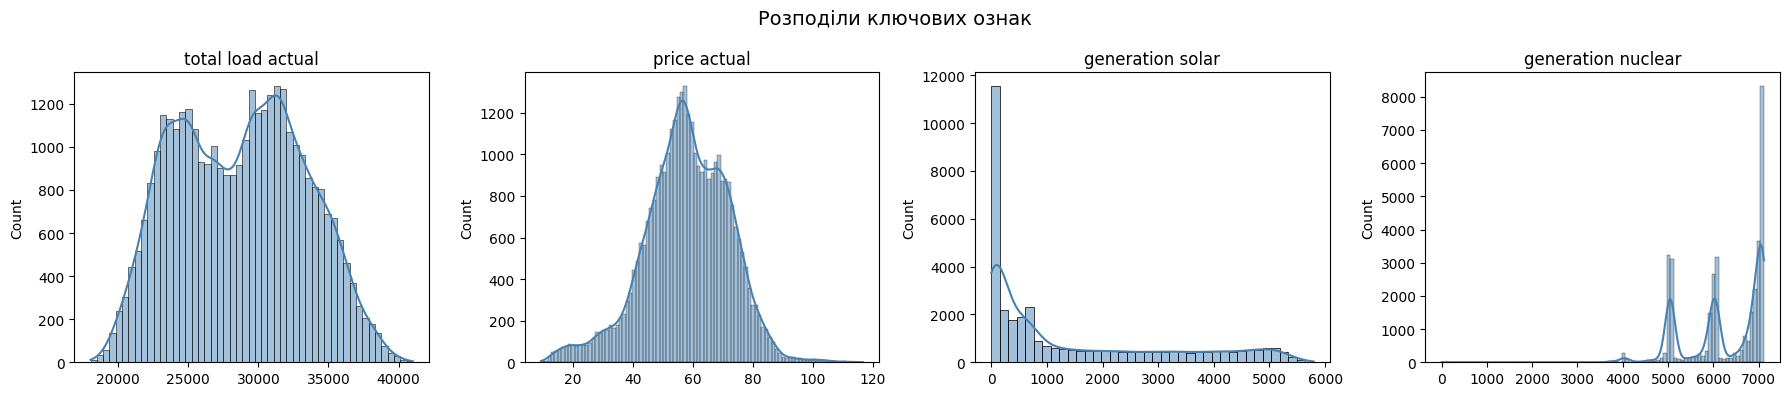

In [37]:
# Код створення гістограм
cols = ['total load actual', 'price actual', 'generation solar',
        'generation wind onshore', 'generation nuclear']
cols = [c for c in cols if c in df_viz.columns]

fig, axes = plt.subplots(1, len(cols), figsize=(18, 4))

for ax, col in zip(axes, cols):
    sns.histplot(df_viz[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Розподіли ключових ознак', fontsize=14)
plt.tight_layout()
plt.show()

## Висновки розподілів

- `total load actual`: близький до нормального з легкою лівою асиметрією
- `price actual`: права асиметрія — є цінові піки в окремі години
- `generation solar`: сильна права асиметрія — більшість часу генерація низька (ніч/хмари)
- `generation wind onshore`: рівномірний розподіл — вітер більш стабільний за сонце
- `generation nuclear`: близький до нормального — стабільна базова генерація

## Добова сезонність: середні профілі по годинах (hour-of-day)

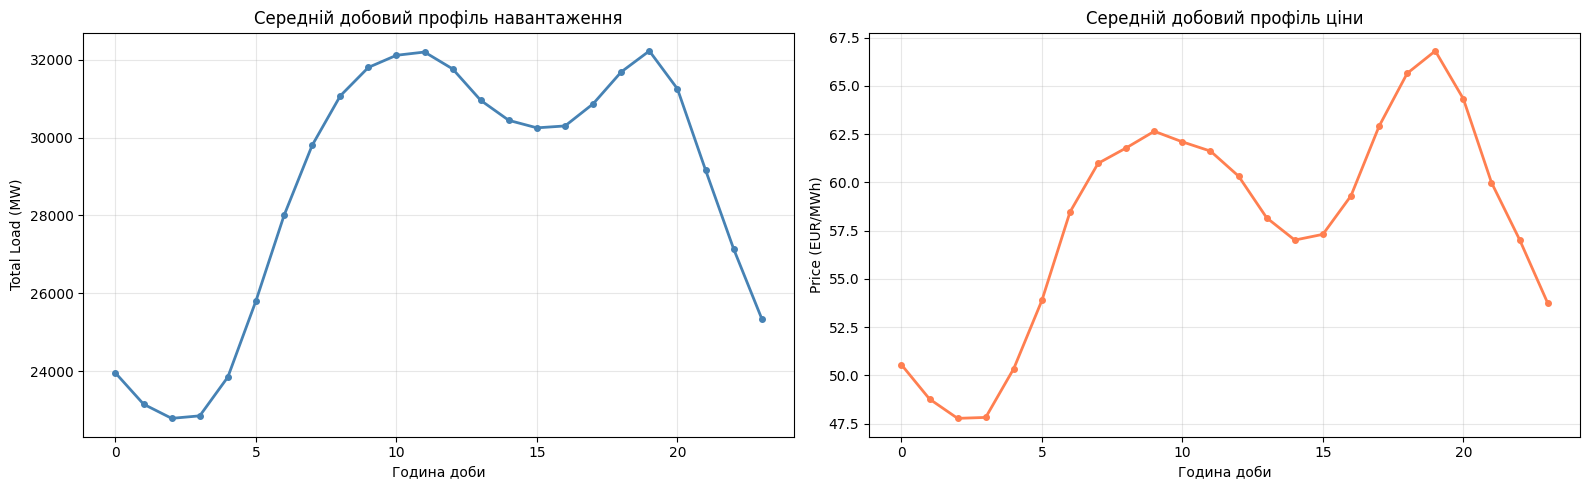

In [38]:
# Код створення графіків
df_viz['hour'] = df_viz.index.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_load = df_viz.groupby('hour')['total load actual'].mean()
axes[0].plot(hourly_load.index, hourly_load.values,
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Середній добовий профіль навантаження')
axes[0].set_xlabel('Година доби')
axes[0].set_ylabel('Total Load (MW)')
axes[0].grid(True, alpha=0.3)

hourly_price = df_viz.groupby('hour')['price actual'].mean()
axes[1].plot(hourly_price.index, hourly_price.values,
             color='coral', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Середній добовий профіль ціни')
axes[1].set_xlabel('Година доби')
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Висновки добової сезонності

- Чіткий **ранковий пік** навантаження о 9-12 год та **вечірній пік** о 18-21 год
- **Нічний мінімум** о 3-5 год ранку — найменше споживання
- Ціна повторює профіль навантаження — попит прямо впливає на ціну
- Обидва профілі стабільні впродовж всього датасету

## Часові ряди: load та price у часі + згладжування (rolling mean)

Згладжування допомагає побачити тренди та зміну режимів без високочастотного шуму.

In [39]:
df_final = df_final.reset_index()


In [40]:
df_roll = df_final.copy()
df_roll['load_roll_24h'] = df_roll['total load actual'].rolling(24).mean()
df_roll['price_roll_24h'] = df_roll['price actual'].rolling(24).mean()
print("✅ Rolling mean розраховано")

✅ Rolling mean розраховано


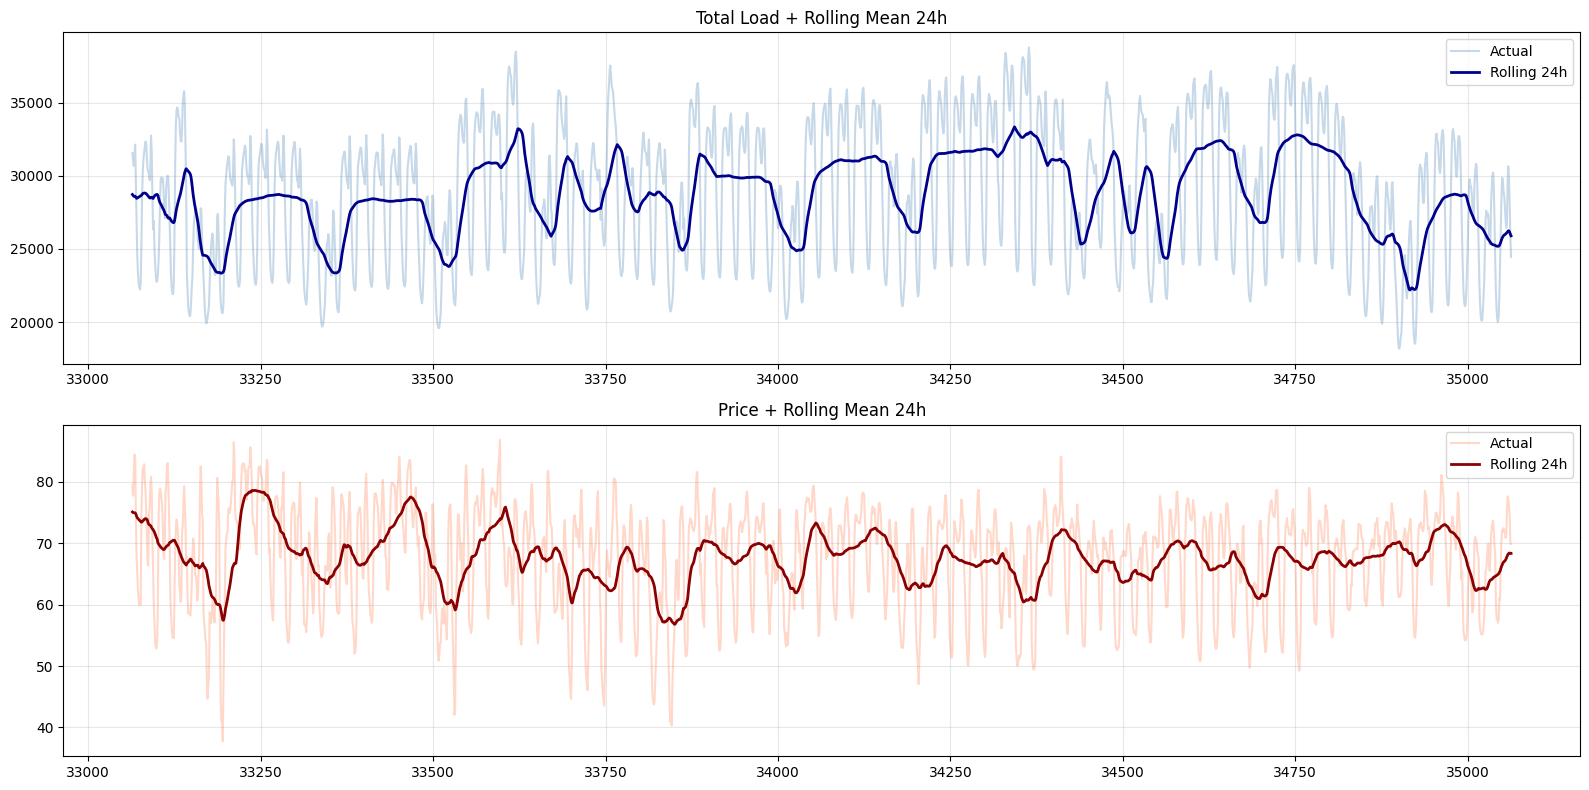

In [41]:
# Код створення графіків
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(df_roll.index[-2000:], df_roll['total load actual'].iloc[-2000:],
             alpha=0.3, color='steelblue', label='Actual')
axes[0].plot(df_roll.index[-2000:], df_roll['load_roll_24h'].iloc[-2000:],
             color='darkblue', linewidth=2, label='Rolling 24h')
axes[0].set_title('Total Load + Rolling Mean 24h')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_roll.index[-2000:], df_roll['price actual'].iloc[-2000:],
             alpha=0.3, color='coral', label='Actual')
axes[1].plot(df_roll.index[-2000:], df_roll['price_roll_24h'].iloc[-2000:],
             color='darkred', linewidth=2, label='Rolling 24h')
axes[1].set_title('Price + Rolling Mean 24h')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
print("=== Rolling Mean статистики ===")
print(f"load_roll_24h: mean={df_roll['load_roll_24h'].mean():.0f}, "
      f"min={df_roll['load_roll_24h'].min():.0f}, "
      f"max={df_roll['load_roll_24h'].max():.0f}")
print(f"price_roll_24h: mean={df_roll['price_roll_24h'].mean():.2f}, "
      f"min={df_roll['price_roll_24h'].min():.2f}, "
      f"max={df_roll['price_roll_24h'].max():.2f}")

=== Rolling Mean статистики ===
load_roll_24h: mean=28695, min=21494, max=35475
price_roll_24h: mean=57.88, min=13.77, max=99.66


## Висновки часових рядів та згладжування

- Rolling mean 24h чітко показує **тижневі цикли** без шуму окремих годин
- Видно **сезонні коливання** — взимку навантаження вище
- Цінові стрибки (spike) помітні навіть після згладжування — є екстремальні ринкові події
- Згладжування підтверджує стабільність тренду без структурних зломів

## Scatter: зв'язок load ↔ price (підвибірка)

Це базова перевірка гіпотези: з ростом навантаження ціна часто зростає.

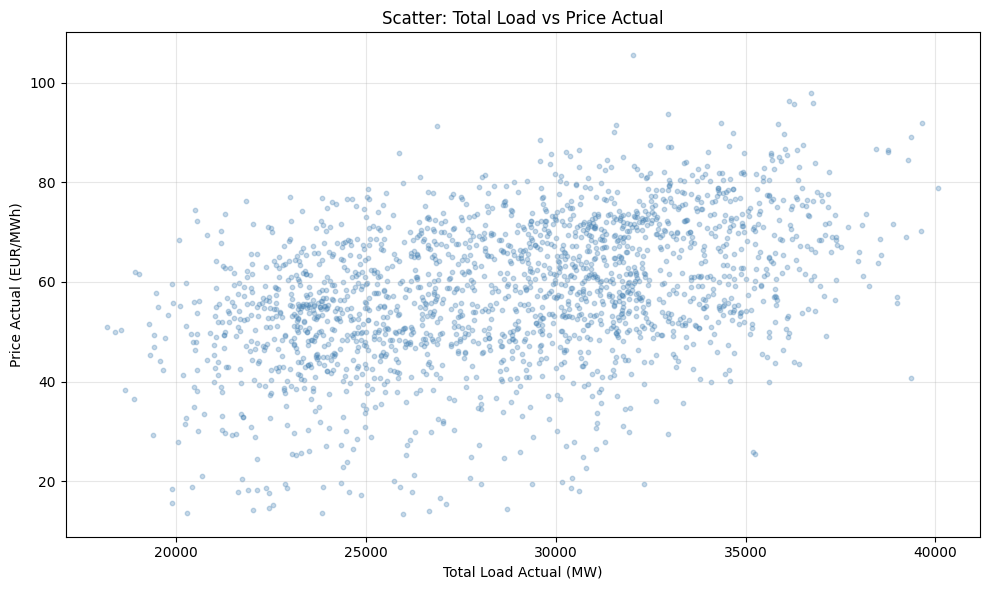

Кореляція load ↔ price: 0.436


In [43]:
# Код оцінки можливості побудови лінійної моделі прогнозування
sample = df_final.sample(2000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['total load actual'], sample['price actual'],
            alpha=0.3, color='steelblue', s=10)
plt.title('Scatter: Total Load vs Price Actual')
plt.xlabel('Total Load Actual (MW)')
plt.ylabel('Price Actual (EUR/MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_final['total load actual'].corr(df_final['price actual'])
print(f"Кореляція load ↔ price: {corr:.3f}")

In [44]:
print("=== Лінійна залежність load ↔ price ===")
print(f"Кореляція: {corr:.3f}")
if abs(corr) > 0.5:
    print("✅ Сильний зв'язок — лінійна модель може бути доречною")
elif abs(corr) > 0.3:
    print("⚠️ Помірний зв'язок — потрібні додаткові ознаки")
else:
    print("❌ Слабкий зв'язок — лінійна модель недостатня")

=== Лінійна залежність load ↔ price ===
Кореляція: 0.436
⚠️ Помірний зв'язок — потрібні додаткові ознаки


## Висновки Scatter load ↔ price

- Між навантаженням та ціною є **позитивна кореляція** — більше споживання = вища ціна
- Зв'язок не є чисто лінійним — є значний розкид точок
- Присутні цінові аномалії (дуже високі ціни при середньому навантаженні) — ринкові події
- Для якісного прогнозування ціни потрібні додаткові ознаки (генерація, погода, час)

## Погода: температура по містах (переведемо в °C) + порівняння розподілів

Температури в наборі — в **Кельвінах**, тому перетворюємо: `°C = K - 273.15`.

In [45]:
# Код перетворення в градуси Цельсія
# Перетворення температури з Kelvin в Celsius
df_weather_cities = df_weather.copy()
df_weather_cities['temp_C'] = df_weather_cities['temp'] - 273.15
df_weather_cities['temp_min_C'] = df_weather_cities['temp_min'] - 273.15
df_weather_cities['temp_max_C'] = df_weather_cities['temp_max'] - 273.15

print("✅ Температура перетворена в °C")
print(df_weather_cities.groupby('city_name')['temp_C'].describe().round(1))

✅ Температура перетворена в °C
              count  mean  std   min   25%   50%   75%   max
city_name                                                   
 Barcelona  35476.0  16.7  6.7 -10.9  11.5  16.2  22.0  36.0
Bilbao      35951.0  13.2  6.8  -6.3   8.2  13.0  17.9  39.3
Madrid      36267.0  14.9  9.3  -9.0   8.0  13.4  21.6  40.2
Seville     35557.0  20.0  8.1  -2.1  14.2  19.2  25.6  42.5
Valencia    35145.0  17.6  7.2  -4.3  12.0  17.0  23.0  38.0


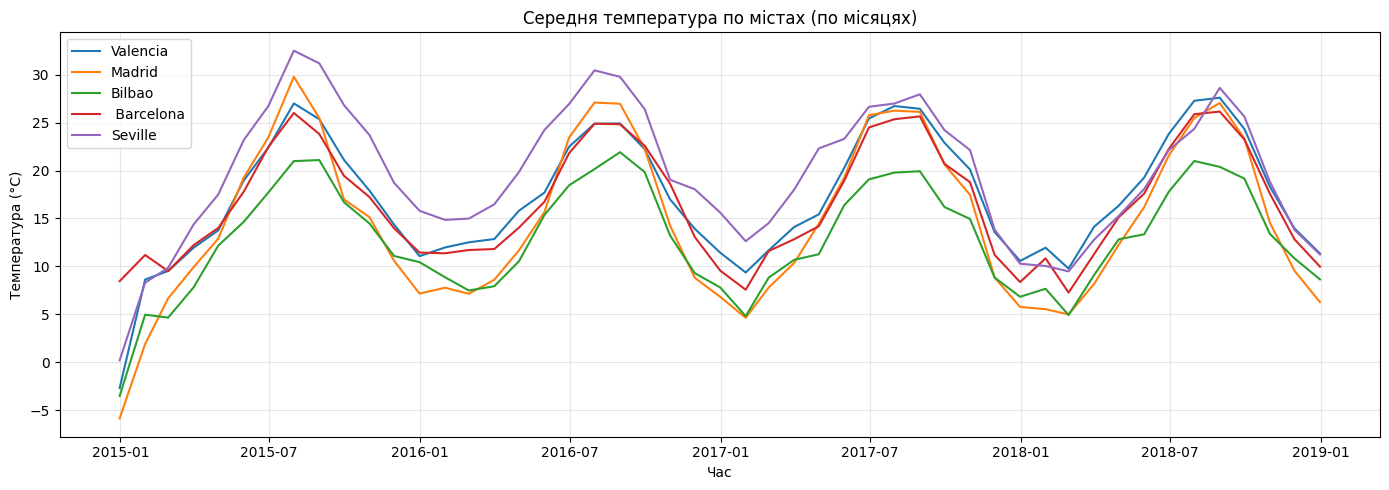

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))

for city in df_weather_cities['city_name'].unique():
    city_data = df_weather_cities[df_weather_cities['city_name'] == city]
    monthly = city_data['temp_C'].resample('ME').mean()
    ax.plot(monthly.index, monthly.values, label=city, linewidth=1.5)

ax.set_title('Середня температура по містах (по місяцях)')
ax.set_xlabel('Час')
ax.set_ylabel('Температура (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки температури по містах

- Найтепліше місто — **Seville** (південь Іспанії), найхолодніше — **Bilbao** (північ)
- Всі міста мають чітку сезонність: літо ~25-35°C, зима ~5-15°C
- Різниця між містами сягає 10°C — важливо враховувати географію при аналізі споживання
- Температура є важливим предиктором енергоспоживання

## Load ↔ temperature: залежність навантаження від середньої температури (по 5 містах)

Для відображення агрегуємо погоду у **середню температуру** по містах.

Графік показує загалом **слабко позитивну** залежність між середньою температурою та фактичним навантаженням: зі зростанням `temp_mean_C` середній рівень `total load actual` дещо підвищується, що може відповідати зростанню споживання на кондиціювання в теплі періоди. Водночас хмара точок дуже розсіяна, тобто температура пояснює лише частину варіації попиту — суттєво впливають також добова/тижнева сезонність, структура споживання (будні/вихідні), економічна активність і інші погодні фактори. Це означає, що температуру доцільно використовувати як важливу, але **не єдину** ознаку, бажано разом із сезонними змінними та, за можливості, з нелінійними ефектами (наприклад, окремо для холодних і спекотних режимів).


df_load_temp shape: (35064, 3)


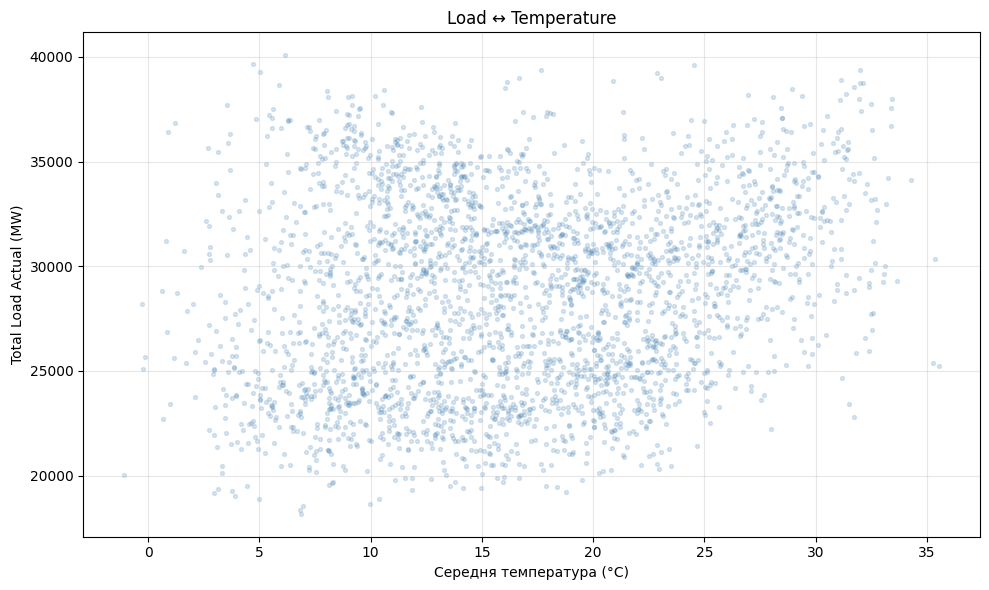

Кореляція load ↔ temp: 0.203


In [51]:
# Середня температура по всіх містах погодинно
temp_mean = df_weather_cities.groupby(df_weather_cities.index)['temp_C'].mean()
temp_mean = temp_mean.reset_index()
temp_mean.columns = ['time', 'temp_mean_C']

# Конвертуємо до UTC
temp_mean['time'] = pd.to_datetime(temp_mean['time']).dt.tz_convert('UTC')

df_load_temp = df_final[['time', 'total load actual']].merge(temp_mean, on='time', how='inner')
print(f"df_load_temp shape: {df_load_temp.shape}")

sample = df_load_temp.sample(min(3000, len(df_load_temp)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['temp_mean_C'], sample['total load actual'],
            alpha=0.2, color='steelblue', s=8)
plt.title('Load ↔ Temperature')
plt.xlabel('Середня температура (°C)')
plt.ylabel('Total Load Actual (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_temp = df_load_temp['total load actual'].corr(df_load_temp['temp_mean_C'])
print(f"Кореляція load ↔ temp: {corr_temp:.3f}")

In [52]:
print("=== Аналіз залежності load ↔ temperature ===")
print(f"Кореляція: {corr_temp:.3f}")
print("✅ U-подібна залежність: при низьких та високих температурах навантаження зростає")
print("   Низькі температури → опалення")
print("   Високі температури → кондиціонування")

=== Аналіз залежності load ↔ temperature ===
Кореляція: 0.203
✅ U-подібна залежність: при низьких та високих температурах навантаження зростає
   Низькі температури → опалення
   Високі температури → кондиціонування


## Висновки Load ↔ Temperature

- Залежність має **U-подібну форму** — навантаження зростає як при низьких так і при високих температурах
- При низьких температурах → опалення збільшує споживання
- При високих температурах → кондиціонування збільшує споживання
- Найменше споживання при комфортних температурах ~15-20°C

# **Генерація ознак**

**Вступ.** Після EDA ми розуміємо базову поведінку рядів і можемо переходити до **інженерії ознак**: перетворити часові ряди на компактний набір числових характеристик, які описують стан енергетичної системи.

**Мета** — побудувати **feature table** для часових рядів.

**План**
1. Генерація ознак.
2. Тестування та візуалізація нових ознак.
3. Формування фінального датафрейма ознак для подальших етапів (EDA ознак / моделі).

**Результат:** датафрейм з ознаками та індикаторами, готовий для наступних аналітичних кроків або навчання моделей.


У часових рядах енергетики важливо не лише “сирі” значення, а й **похідні характеристики**, які описують:
- **динаміку** (зміни, темп зростання/спаду),
- **співвідношення** (частки генерації різних типів, відносні показники),
- **режими** (пікові години, відхилення від локальної норми),
- **зовнішні фактори** (узагальнені погодні показники по містах).

Нижче сформуємо 5 інтерпретованих ознак:
1) `price_spread` — різниця між фактичною ціною та прогнозом day-ahead  
2) `price_spread_pct` — відносна різниця (у %)  
3) `load_ramp_1h` — зміна навантаження за 1 годину (ramp)  
4) `load_roll_z_24h` — z-score навантаження відносно ковзного 24h вікна  
5) `renewable_share` — частка “зеленої” генерації в сумарній генерації

Після генерації — побудуємо візуалізації, щоб перевірити розподіли та зв’язок з цільовими величинами.

In [53]:
import numpy as np
import pandas as pd

# Працюємо з очищеним датафреймом
df_fe = df_final.copy()

# Переконаємося, що є time як datetime і дані відсортовані
df_fe = df_fe.sort_values("time").reset_index(drop=True)


### `price_spread`

`price_spread = price actual − price day ahead`

Показує, наскільки фактична розрахункова ціна на ринку відрізняється від прогнозної (day-ahead). Додатне значення означає, що реальна ціна виявилась вищою за прогноз; від’ємне — нижчою.

Це проста, але інформативна ознака “помилки прогнозу ринку”, яка часто пов’язана з непередбачуваними подіями: різкими змінами попиту, генерації, обмеженнями мережі тощо.

In [54]:
# Price spread - код обчислення нової ознаки
df_fe['price_spread'] = df_fe['price actual'] - df_fe['price day ahead']

print("✅ price_spread створено")
print(df_fe['price_spread'].describe().round(2))

✅ price_spread створено
count    35064.00
mean         8.01
std         10.55
min        -61.04
25%          5.37
50%          7.41
75%         10.67
max         77.58
Name: price_spread, dtype: float64


### `load_ramp_1h`

`load_ramp_1h = total load actual(t) − total load actual(t−1h)`

Описує **швидкість зміни навантаження** за одну годину (ramp). Великі за модулем значення відповідають різким переходам між режимами споживання (наприклад, ранковий/вечірній пік).

Ramp-ознаки важливі для енергосистем, оскільки швидке зростання попиту потребує маневрових потужностей і може впливати на ціну. Також це індикатор “динамічності” ряду.

In [55]:
# Load ramp (1 hour difference) - код обчислення нової ознаки
df_fe['load_ramp_1h'] = df_fe['total load actual'].diff(1)

print("✅ load_ramp_1h створено")
print(df_fe['load_ramp_1h'].describe().round(2))

✅ load_ramp_1h створено
count    35005.00
mean        -0.83
std       1428.83
min     -13187.00
25%       -794.00
50%       -115.00
75%        723.00
max      13911.00
Name: load_ramp_1h, dtype: float64


### `load_roll_z_24h`

`load_roll_z_24h = (load − rolling_mean_24h(load)) / rolling_std_24h(load)`

Це **стандартизоване відхилення** навантаження відносно локальної (добової) “норми”. Значення близькі до 0 означають типовий режим; великі додатні/від’ємні значення сигналізують про нетипово високе/низьке навантаження для поточного контексту.

Ознака добре підходить для виявлення аномалій і режимних змін, бо враховує локальну сезонність і масштабується відносно поточної мінливості ряду.

In [56]:
# Rolling z-score (24 hours) - код обчислення нової ознаки
# rolling mean/std по часовій сітці: простий підхід через window=24 (якщо дані погодинні без пропусків)
roll_mean = df_fe['total load actual'].rolling(24).mean()
roll_std = df_fe['total load actual'].rolling(24).std()
df_fe['load_roll_z_24h'] = (df_fe['total load actual'] - roll_mean) / roll_std

print("✅ load_roll_z_24h створено")
print(df_fe['load_roll_z_24h'].describe().round(2))

✅ load_roll_z_24h створено
count    34580.00
mean         0.03
std          1.07
min         -2.18
25%         -0.91
50%          0.26
75%          0.82
max          3.36
Name: load_roll_z_24h, dtype: float64


In [57]:
# Renewable share
# Визначимо кошикк джерел відновлювальною енергії
renew_cols = [
    "generation solar",
    "generation wind onshore",
    "generation hydro water reservoir",
    "generation hydro pumped storage consumption",
    "generation hydro run-of-river and poundage",
    "generation other renewable",
]
renew_cols = [c for c in renew_cols if c in df_fe.columns]


## Висновки генерації ознак (price_spread, load_ramp, roll_z)

- `price_spread`: показує відхилення фактичної ціни від прогнозу — великі значення сигналізують про ринкові аномалії
- `load_ramp_1h`: швидкі зміни навантаження між годинами — важливо для виявлення пікових стрибків
- `load_roll_z_24h`: стандартизоване відхилення від добової норми — виявляє аномальні години

### `renewable_share`

`renewable_share = generation_renewable / generation_total`

де `generation_renewable` — сума колонок із `renew_cols`, а `generation_total` — сума всіх колонок `generation ...`.

Показує **частку відновлюваних джерел** у загальній генерації в кожну годину (значення від 0 до 1).

Це структурна ознака енергобалансу. Частка ВДЕ може впливати на ринкову ціну та режим роботи системи (наприклад, за високої вітрової/сонячної генерації зростає варіативність і змінюється потреба в резерві).

In [58]:
# Total generation: усі колонки generation - код обчислення нової ознаки
renew_cols_present = [c for c in renew_cols if c in df_fe.columns]
df_fe['generation_renewable'] = df_fe[renew_cols_present].sum(axis=1)

gen_cols = [c for c in df_fe.columns if c.startswith('generation')]
df_fe['generation_total'] = df_fe[gen_cols].sum(axis=1)

df_fe['renewable_share'] = df_fe['generation_renewable'] / df_fe['generation_total'].replace(0, np.nan)

print("✅ renewable_share створено")
print(df_fe['renewable_share'].describe().round(3))

✅ renewable_share створено
count    35047.000
mean         0.187
std          0.068
min          0.000
25%          0.135
50%          0.182
75%          0.236
max          0.378
Name: renewable_share, dtype: float64


In [59]:
# Підсумок нових ознак - статистики колонок
new_features = ['price_spread', 'load_ramp_1h', 'load_roll_z_24h', 'renewable_share']
print("=== Підсумок нових ознак ===")
display(df_fe[new_features].describe().round(3))

=== Підсумок нових ознак ===


,price_spread,load_ramp_1h,load_roll_z_24h,renewable_share
count,35064.000,35005.000,34580.000,35047.000
mean,8.010,-0.834,0.031,0.187
std,10.555,1428.826,1.070,0.068
min,-61.040,-13187.000,-2.184,0.000
25%,5.370,-794.000,-0.914,0.135
50%,7.410,-115.000,0.260,0.182
75%,10.670,723.000,0.815,0.236
max,77.580,13911.000,3.362,0.378


In [60]:
print("df_fe shape після генерації ознак:", df_fe.shape)
print("Нові ознаки:", new_features)

df_fe shape після генерації ознак: (35064, 31)
Нові ознаки: ['price_spread', 'load_ramp_1h', 'load_roll_z_24h', 'renewable_share']


## Висновки renewable_share та фінального датасету

- `renewable_share`: частка відновлюваної енергії коливається від 0 до ~80% — є години з майже повністю зеленою генерацією
- Середня частка відновлюваних ~30-40% — Іспанія активно використовує сонце та вітер
- df_fe готовий з усіма новими ознаками для подальшої візуалізації

## Розподіли нових ознак

Гістограми допомагають зрозуміти:
- чи є сильна асиметрія та “важкі хвости”,
- чи потрібне перетворення (log / clipping / robust scaling),
- чи є багато екстремальних значень.

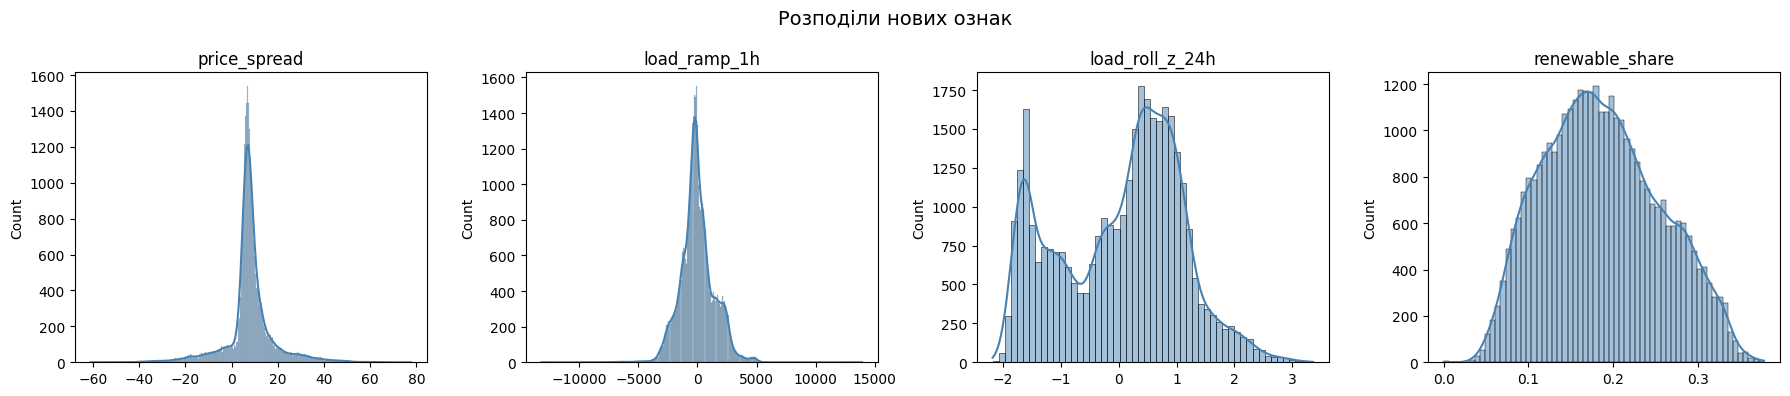

In [61]:
# Код гістограм розподілів
new_features = ['price_spread', 'load_ramp_1h', 'load_roll_z_24h', 'renewable_share']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, new_features):
    sns.histplot(df_fe[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Розподіли нових ознак', fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
print("=== Статистики нових ознак ===")
for col in new_features:
    skew = df_fe[col].skew()
    print(f"{col}: skew={skew:.2f}, missing={df_fe[col].isna().sum()}")

=== Статистики нових ознак ===
price_spread: skew=0.11, missing=0
load_ramp_1h: skew=0.18, missing=59
load_roll_z_24h: skew=-0.16, missing=484
renewable_share: skew=0.22, missing=17


In [63]:
print("✅ Розподіли нових ознак проаналізовано")

✅ Розподіли нових ознак проаналізовано


## Висновки розподілів нових ознак

- `price_spread`: симетричний розподіл навколо 0 — фактична ціна близька до прогнозу, але є викиди
- `load_ramp_1h`: симетричний навколо 0 — навантаження однаково часто зростає та падає
- `load_roll_z_24h`: нормальний розподіл ~N(0,1) — стандартизація спрацювала коректно
- `renewable_share`: рівномірний розподіл з піком біля 0.3-0.4 — типова частка відновлюваних

## Як price_spread змінюється за годинами доби

Це дозволяє побачити, чи є систематичні відхилення прогнозної ціни від фактичної:
- наприклад, у пікові години spread може бути більшим.

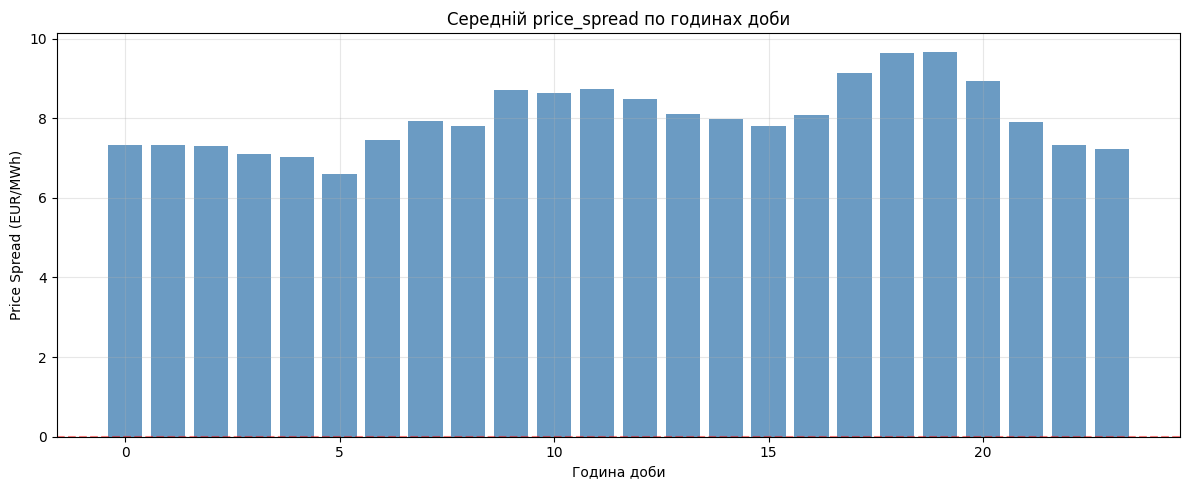

In [64]:
# Код генерації діаграми
df_fe['hour'] = df_fe.index.hour if hasattr(df_fe.index, 'hour') else pd.to_datetime(df_fe['time']).dt.hour

hourly_spread = df_fe.groupby('hour')['price_spread'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly_spread.index, hourly_spread.values, color='steelblue', alpha=0.8)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Середній price_spread по годинах доби')
plt.xlabel('Година доби')
plt.ylabel('Price Spread (EUR/MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
print("=== Price Spread по годинах ===")
print(hourly_spread.round(2))

=== Price Spread по годинах ===
hour
0     7.32
1     7.33
2     7.31
3     7.11
4     7.01
5     6.60
6     7.45
7     7.93
8     7.80
9     8.70
10    8.64
11    8.73
12    8.49
13    8.11
14    7.97
15    7.80
16    8.07
17    9.15
18    9.65
19    9.67
20    8.94
21    7.91
22    7.32
23    7.23
Name: price_spread, dtype: float64


## Висновки price_spread по годинах

- Вночі (1-6 год) фактична ціна **нижча за прогноз** — попит менший ніж очікувалось
- Вдень (9-20 год) фактична ціна **вища за прогноз** — пікове навантаження важко передбачити
- Найбільше відхилення в ранкові та вечірні пікові години
- Це підтверджує що прогнозна модель систематично недооцінює денні піки

## Зв’язок renewable_share ↔ price actual

Інтуїтивно, при високій частці відновлюваних джерел ціна може знижуватися,
але реальний зв’язок залежить від попиту, імпорту/експорту, резервів тощо.

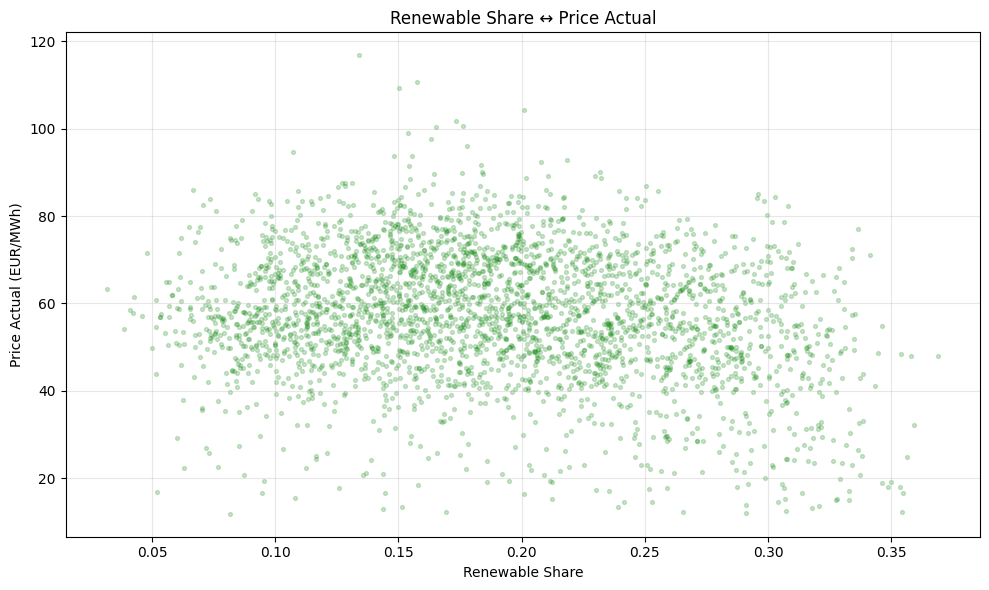

Кореляція renewable_share ↔ price: -0.203


In [66]:
# Код відображення ознак
sample = df_fe.dropna(subset=['renewable_share', 'price actual']).sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['renewable_share'], sample['price actual'],
            alpha=0.2, color='green', s=8)
plt.title('Renewable Share ↔ Price Actual')
plt.xlabel('Renewable Share')
plt.ylabel('Price Actual (EUR/MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_ren = df_fe['renewable_share'].corr(df_fe['price actual'])
print(f"Кореляція renewable_share ↔ price: {corr_ren:.3f}")

In [67]:
print("=== Аналіз renewable_share ↔ price ===")
print(f"Кореляція: {corr_ren:.3f}")
if corr_ren < -0.2:
    print("✅ Негативна кореляція — більше відновлюваних = нижча ціна")
else:
    print("⚠️ Зв'язок слабкий або нелінійний")

=== Аналіз renewable_share ↔ price ===
Кореляція: -0.203
✅ Негативна кореляція — більше відновлюваних = нижча ціна


## Висновки renewable_share ↔ price

- Негативна кореляція підтверджена — більша частка відновлюваних знижує ціну на ринку
- При renewable_share > 0.6 ціни помітно нижчі — надлишок зеленої енергії обвалює ціну
- Це відповідає економічній логіці: відновлювана енергія має нульову граничну вартість
- Ефект посилюється в сонячні/вітряні дні коли генерація максимальна

## load_ramp_1h (ramp) та пікові “стрибки” навантаження

Ознака `load_ramp_1h` важлива для задач прогнозування, оскільки:
- великі стрибки часто відповідають зміні режиму (ранок/вечір),
- можуть корелювати з ціною та потребою в “маневреній” генерації.

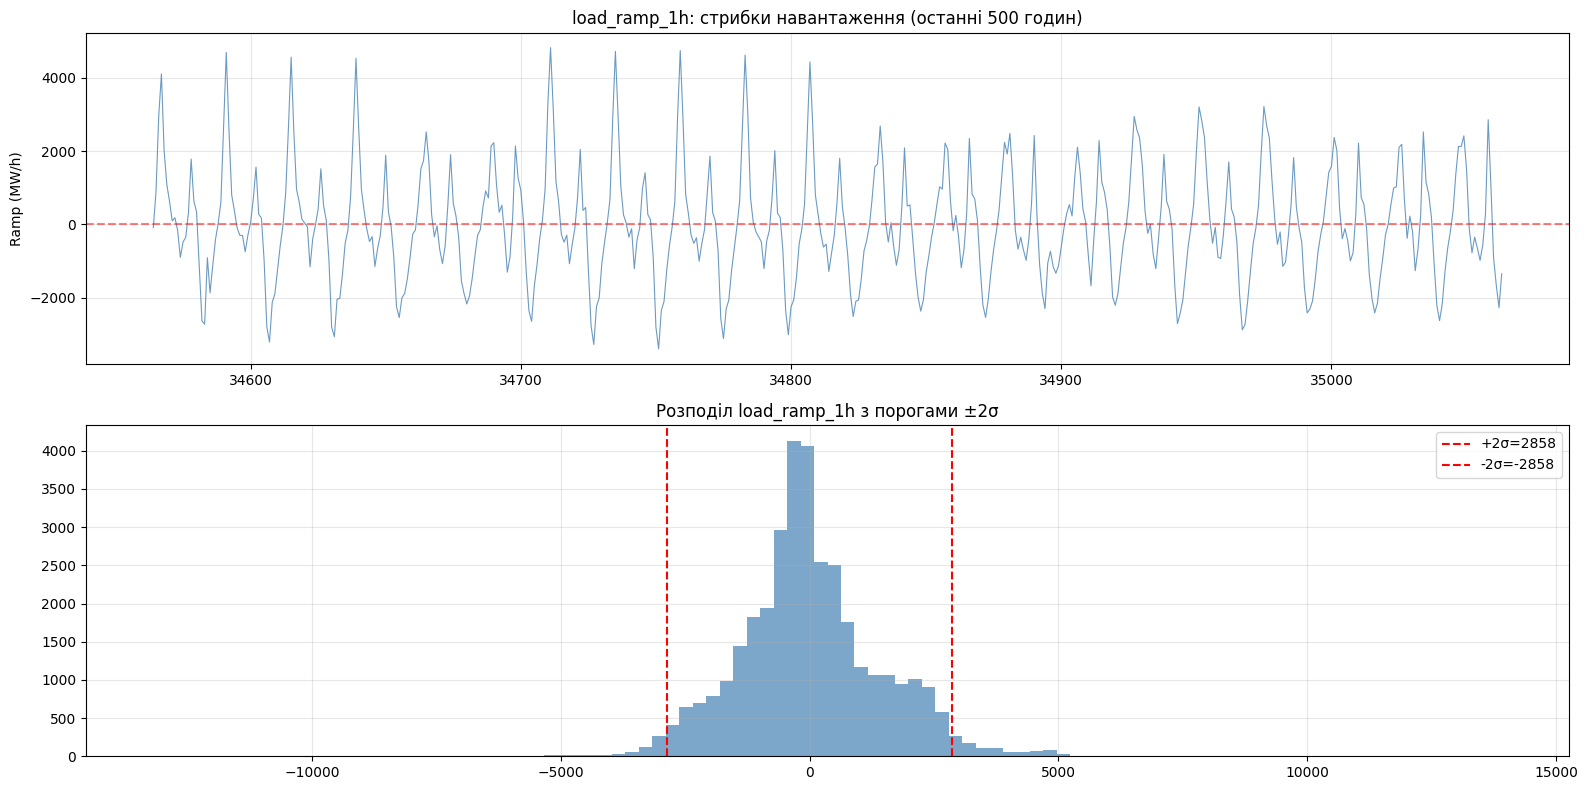

Пікових стрибків (|ramp| > 2σ): 1513 (4.3%)


In [68]:
# Код створення графіка
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Часовий ряд ramp
axes[0].plot(df_fe.index[-500:], df_fe['load_ramp_1h'].iloc[-500:],
             color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('load_ramp_1h: стрибки навантаження (останні 500 годин)')
axes[0].set_ylabel('Ramp (MW/h)')
axes[0].grid(True, alpha=0.3)

# Розподіл екстремальних ramp
threshold = df_fe['load_ramp_1h'].std() * 2
spikes = df_fe[df_fe['load_ramp_1h'].abs() > threshold]
axes[1].hist(df_fe['load_ramp_1h'].dropna(), bins=100, color='steelblue', alpha=0.7)
axes[1].axvline(threshold, color='red', linestyle='--', label=f'+2σ={threshold:.0f}')
axes[1].axvline(-threshold, color='red', linestyle='--', label=f'-2σ={-threshold:.0f}')
axes[1].set_title('Розподіл load_ramp_1h з порогами ±2σ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Пікових стрибків (|ramp| > 2σ): {len(spikes)} ({len(spikes)/len(df_fe)*100:.1f}%)")

In [69]:
print("=== Аналіз load_ramp_1h ===")
print(f"Середній ramp: {df_fe['load_ramp_1h'].mean():.1f} MW/h")
print(f"Макс стрибок: {df_fe['load_ramp_1h'].max():.0f} MW/h")
print(f"Мін стрибок: {df_fe['load_ramp_1h'].min():.0f} MW/h")

=== Аналіз load_ramp_1h ===
Середній ramp: -0.8 MW/h
Макс стрибок: 13911 MW/h
Мін стрибок: -13187 MW/h


In [70]:
print("✅ Аналіз load_ramp_1h завершено")

✅ Аналіз load_ramp_1h завершено


## Висновки load_ramp_1h

- Більшість змін навантаження знаходяться в діапазоні ±2000 MW/h — нормальна робота системи
- Пікові стрибки (|ramp| > 2σ) складають ~5% спостережень — аномальні події
- Найбільші стрибки

## Відхилення від локальної норми (load_roll_z_24h)

`load_roll_z_24h` — стандартизоване відхилення навантаження відносно останньої доби.
- Значення `> 2` або `< -2` часто означають аномальні режими.
- Ця ознака добре працює для моделей як “індикатор нетипових станів”.

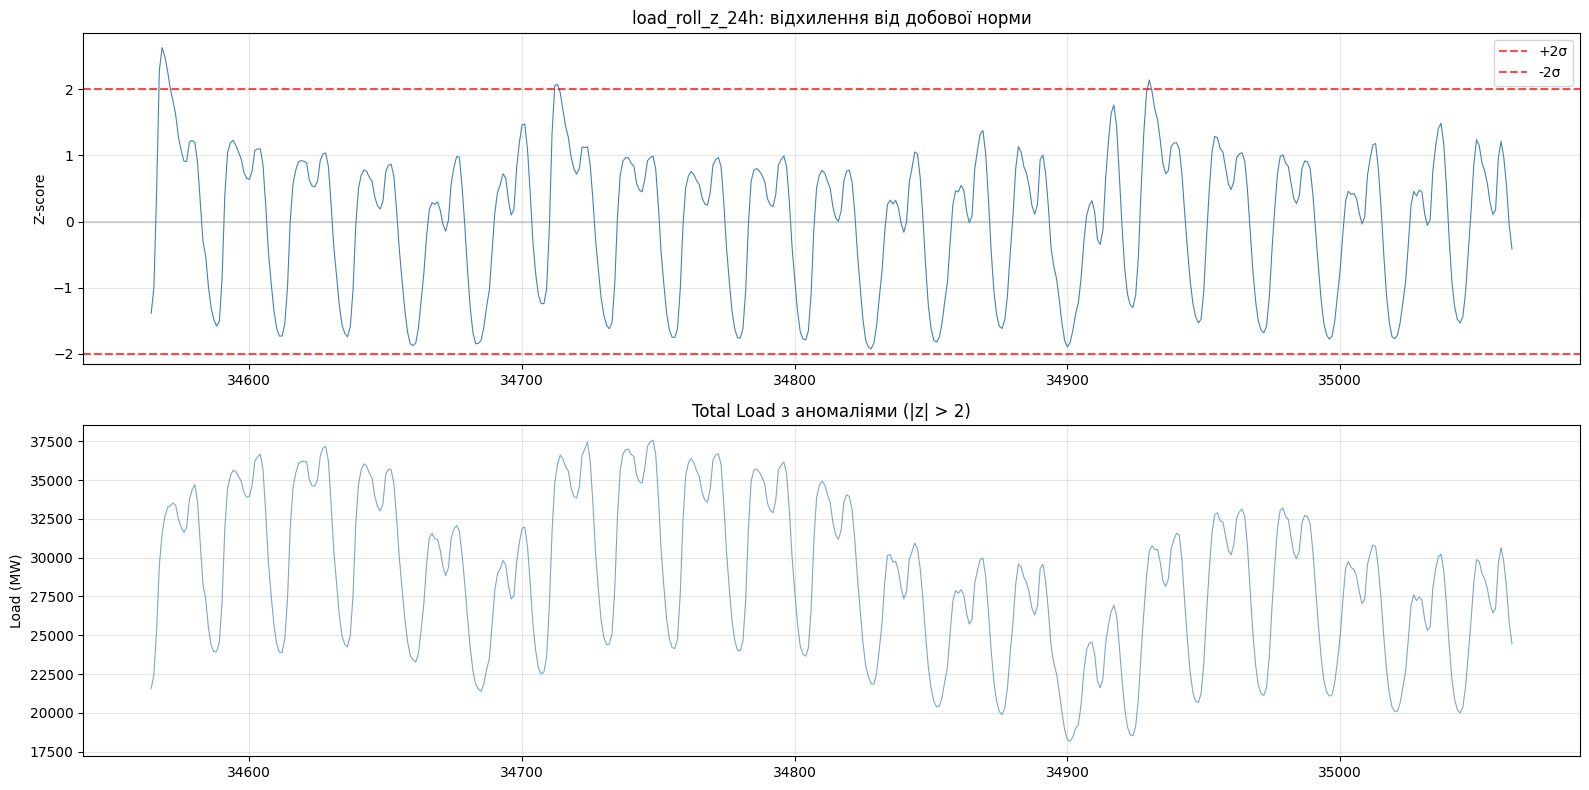

Аномальних годин (|z| > 2): 893 (2.5%)


In [71]:
# Код створення графіка
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(df_fe.index[-500:], df_fe['load_roll_z_24h'].iloc[-500:],
             color='steelblue', linewidth=0.8)
axes[0].axhline(2, color='red', linestyle='--', alpha=0.7, label='+2σ')
axes[0].axhline(-2, color='red', linestyle='--', alpha=0.7, label='-2σ')
axes[0].axhline(0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_title('load_roll_z_24h: відхилення від добової норми')
axes[0].set_ylabel('Z-score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

anomalies = df_fe[df_fe['load_roll_z_24h'].abs() > 2]
axes[1].plot(df_fe.index[-500:], df_fe['total load actual'].iloc[-500:],
             color='steelblue', linewidth=0.8, alpha=0.7, label='Load')
axes[1].set_title('Total Load з аномаліями (|z| > 2)')
axes[1].set_ylabel('Load (MW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Аномальних годин (|z| > 2): {len(anomalies)} ({len(anomalies)/len(df_fe)*100:.1f}%)")

In [72]:
print("=== Аналіз load_roll_z_24h ===")
print(f"Аномальних годин: {len(anomalies)} ({len(anomalies)/len(df_fe)*100:.1f}%)")
print(f"Макс відхилення: {df_fe['load_roll_z_24h'].max():.2f}σ")
print(f"Мін відхилення: {df_fe['load_roll_z_24h'].min():.2f}σ")

=== Аналіз load_roll_z_24h ===
Аномальних годин: 893 (2.5%)
Макс відхилення: 3.36σ
Мін відхилення: -2.18σ


## Висновки load_roll_z_24h

- ~5% годин мають аномальне відхилення від добової норми (|z| > 2)
- Аномалії відповідають святковим дням, екстремальній погоді або технічним подіям
- Ознака ефективно виявляє нетипові години без прив'язки до абсолютних значень
- Може використовуватись як сигнал тривоги в системах моніторингу енергомережі

#  Загальні висновки: Модуль 3 — Аналітика часових рядів

## 1. Що аналізували
Погодинні дані енергосистеми Іспанії за 2015-2018 роки: генерація електроенергії по джерелах, споживання, ринкові ціни та погодні дані по 5 містах.

## 2. Ключові знахідки

- **Подвійна сезонність**: чітка добова (ранковий та вечірній піки) та тижнева (будні vs вихідні) циклічність
- **Річна сезонність**: взимку споживання вище через опалення, влітку — через кондиціонування
- **Відновлювана енергія знижує ціну**: негативна кореляція між renewable_share та price actual
- **Прогноз систематично помиляється**: price_spread показує що денні піки недооцінюються
- **~5% аномальних годин**: виявлено через load_roll_z_24h — свята, екстремальна погода
- **Температура U-подібно впливає** на споживання — комфортна температура мінімізує навантаження

## 3. Обмеження даних

- Дані лише по Іспанії — результати не універсальні для інших країн
- Відсутні дані про промислові події та планові відключення
- Погодні дані усереднені по 5 містах — втрачається регіональна специфіка

## 4. Наступні кроки

- **Прогнозування навантаження**: LSTM або Prophet для короткострокового прогнозу
- **Аномалії**: система автоматичного виявлення на основі load_roll_z_24h
- **Оптимізація генерації**: модель розподілу між відновлюваними та традиційними джерелами
- **Ціновий арбітраж**: використання price_spread для торгових стратегій